# 3. Proposed System

**Research question.** Can ensemble weighting, fuzzy gating and/or a hybrid deep-learning model improve on the baselines from notebook 02 — and at what cost (calibration, coverage, compute)?

This notebook covers three components built on top of the baselines: (a) multi-objective ensemble weight optimisation (NSGA-II / PSO), (b) neuro-fuzzy gating, and (c) the hybrid deep-learning model.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from _common import load_json, show_md, show_fig, show_thesis_fig, metrics_table, RESULTS, FIGURES, DATA
from IPython.display import display
import pandas as pd
pd.set_option('display.max_colwidth', 120)

## 3.1 Ensemble weight optimisation (NSGA-II)

Source: `backend/results/multi_objective_ensemble.md`.

In [2]:
show_md('multi_objective_ensemble.md')

# Multi-Objective Ensemble Optimisation (NSGA-II)

## Setup

- **Models**: logreg, svm, tfidf
- **Objectives**: Macro-F1 (↑), ECE (↓), Coverage@70% (↑)
- **Algorithm**: NSGA-II  (pop=60, gen=80)
- **Evaluations**: 4,860
- **Runtime**: 418.5s
- **Pareto front size**: 60 solutions

## Pareto Front (Validation Set)

| Rank | w(logreg) | w(svm) | w(tfidf) | Macro-F1 | ECE | Coverage |
|------|------|------|------|----------|-----|----------|
|    1 | 0.806 | 0.099 | 0.095 | 0.6923 | 0.0138 | 0.4616 |
|    2 | 0.085 | 0.057 | 0.858 | 0.6627 | 0.0074 | 0.4136 |
|    3 | 0.999 | 0.000 | 0.001 | 0.6891 | 0.0140 | 0.4776 |
|    4 | 0.940 | 0.000 | 0.060 | 0.6900 | 0.0147 | 0.4714 |
|    5 | 0.071 | 0.000 | 0.928 | 0.6578 | 0.0113 | 0.4196 |
|    6 | 0.182 | 0.001 | 0.817 | 0.6670 | 0.0120 | 0.4163 |
|    7 | 0.807 | 0.098 | 0.095 | 0.6923 | 0.0137 | 0.4615 |
|    8 | 0.870 | 0.128 | 0.001 | 0.6889 | 0.0123 | 0.4725 |
|    9 | 0.144 | 0.012 | 0.844 | 0.6636 | 0.0087 | 0.4159 |
|   10 | 0.160 | 0.001 | 0.839 | 0.6640 | 0.0094 | 0.4159 |
|   11 | 0.094 | 0.003 | 0.903 | 0.6590 | 0.0105 | 0.4175 |
|   12 | 0.086 | 0.000 | 0.914 | 0.6584 | 0.0108 | 0.4184 |
|   13 | 0.163 | 0.010 | 0.827 | 0.6654 | 0.0102 | 0.4153 |
|   14 | 0.170 | 0.000 | 0.830 | 0.6649 | 0.0116 | 0.4158 |
|   15 | 0.114 | 0.004 | 0.882 | 0.6608 | 0.0105 | 0.4175 |
|   16 | 0.178 | 0.002 | 0.821 | 0.6667 | 0.0117 | 0.4159 |
|   17 | 0.950 | 0.049 | 0.001 | 0.6895 | 0.0134 | 0.4756 |
|   18 | 0.869 | 0.047 | 0.083 | 0.6917 | 0.0142 | 0.4651 |
|   19 | 0.086 | 0.057 | 0.856 | 0.6629 | 0.0076 | 0.4138 |
|   20 | 0.073 | 0.000 | 0.926 | 0.6580 | 0.0119 | 0.4193 |
|   21 | 0.109 | 0.003 | 0.887 | 0.6609 | 0.0114 | 0.4175 |
|   22 | 0.084 | 0.001 | 0.916 | 0.6581 | 0.0112 | 0.4185 |
|   23 | 0.156 | 0.000 | 0.844 | 0.6634 | 0.0082 | 0.4159 |
|   24 | 0.938 | 0.000 | 0.062 | 0.6902 | 0.0144 | 0.4709 |
|   25 | 0.102 | 0.001 | 0.897 | 0.6600 | 0.0110 | 0.4176 |
|   26 | 0.160 | 0.002 | 0.838 | 0.6642 | 0.0094 | 0.4158 |
|   27 | 0.916 | 0.003 | 0.081 | 0.6903 | 0.0122 | 0.4679 |
|   28 | 0.937 | 0.002 | 0.061 | 0.6901 | 0.0144 | 0.4710 |
|   29 | 0.102 | 0.001 | 0.897 | 0.6600 | 0.0110 | 0.4176 |
|   30 | 0.132 | 0.001 | 0.868 | 0.6621 | 0.0080 | 0.4170 |
|   31 | 0.130 | 0.001 | 0.869 | 0.6618 | 0.0079 | 0.4170 |
|   32 | 0.815 | 0.094 | 0.091 | 0.6921 | 0.0133 | 0.4622 |
|   33 | 0.899 | 0.021 | 0.080 | 0.6909 | 0.0128 | 0.4667 |
|   34 | 0.124 | 0.054 | 0.822 | 0.6657 | 0.0113 | 0.4141 |
|   35 | 0.913 | 0.081 | 0.007 | 0.6899 | 0.0139 | 0.4739 |
|   36 | 0.885 | 0.011 | 0.104 | 0.6915 | 0.0127 | 0.4640 |
|   37 | 0.091 | 0.001 | 0.908 | 0.6586 | 0.0100 | 0.4180 |
|   38 | 0.906 | 0.003 | 0.091 | 0.6904 | 0.0124 | 0.4672 |
|   39 | 0.820 | 0.091 | 0.089 | 0.6920 | 0.0129 | 0.4630 |
|   40 | 0.928 | 0.000 | 0.072 | 0.6901 | 0.0135 | 0.4695 |
|   41 | 0.130 | 0.002 | 0.867 | 0.6622 | 0.0084 | 0.4170 |
|   42 | 0.139 | 0.001 | 0.860 | 0.6624 | 0.0097 | 0.4170 |
|   43 | 0.912 | 0.087 | 0.001 | 0.6893 | 0.0134 | 0.4739 |
|   44 | 0.892 | 0.039 | 0.069 | 0.6908 | 0.0132 | 0.4674 |
|   45 | 0.873 | 0.127 | 0.000 | 0.6889 | 0.0130 | 0.4728 |
|   46 | 0.988 | 0.008 | 0.004 | 0.6892 | 0.0139 | 0.4773 |
|   47 | 0.124 | 0.048 | 0.828 | 0.6645 | 0.0102 | 0.4138 |
|   48 | 0.131 | 0.001 | 0.868 | 0.6618 | 0.0078 | 0.4168 |
|   49 | 0.829 | 0.086 | 0.085 | 0.6920 | 0.0125 | 0.4635 |
|   50 | 0.926 | 0.000 | 0.074 | 0.6905 | 0.0126 | 0.4686 |
|   51 | 0.155 | 0.001 | 0.844 | 0.6634 | 0.0083 | 0.4160 |
|   52 | 0.906 | 0.031 | 0.063 | 0.6906 | 0.0135 | 0.4689 |
|   53 | 0.887 | 0.035 | 0.078 | 0.6911 | 0.0138 | 0.4657 |
|   54 | 0.890 | 0.004 | 0.107 | 0.6913 | 0.0131 | 0.4644 |
|   55 | 0.160 | 0.001 | 0.839 | 0.6641 | 0.0098 | 0.4159 |
|   56 | 0.893 | 0.028 | 0.079 | 0.6911 | 0.0134 | 0.4664 |
|   57 | 0.874 | 0.034 | 0.092 | 0.6916 | 0.0138 | 0.4647 |
|   58 | 0.110 | 0.060 | 0.830 | 0.6644 | 0.0099 | 0.4138 |
|   59 | 0.136 | 0.000 | 0.864 | 0.6625 | 0.0086 | 0.4169 |
|   60 | 0.136 | 0.000 | 0.864 | 0.6625 | 0.0086 | 0.4166 |

## Knee-Point Selection

The recommended operating point minimises the normalised Chebyshev distance to the ideal point — balancing all three objectives.

**Knee-point index** (1-based): 27

### Optimal Weights

| Model | Weight |
|-------|--------|
| logreg | 0.9161 |
| svm | 0.0027 |
| tfidf | 0.0812 |

## Validation Performance (knee-point)

| Metric | Value |
|--------|-------|
| Macro-F1 | 0.6903 |
| ECE | 0.0122 |
| Coverage@70% | 0.4679 |

## Test-Set Performance (knee-point)

| Metric | Value |
|--------|-------|
| Macro-F1 | 0.6940 |
| ECE | 0.0039 |
| Coverage@70% | 0.4711 |

## Thesis Interpretation

The Pareto front reveals that ensemble calibration and accuracy are partially competing: aggressive weight concentration (LogReg dominant) maximises F1 but raises ECE, while more balanced weights improve calibration at a small accuracy cost. The knee-point solution provides a principled, calibration-aware alternative to the single-objective PSO solution reported in §4.3, demonstrating that the CI contribution extends beyond raw accuracy improvement to probabilistic reliability — a key requirement for deployed sentiment systems.


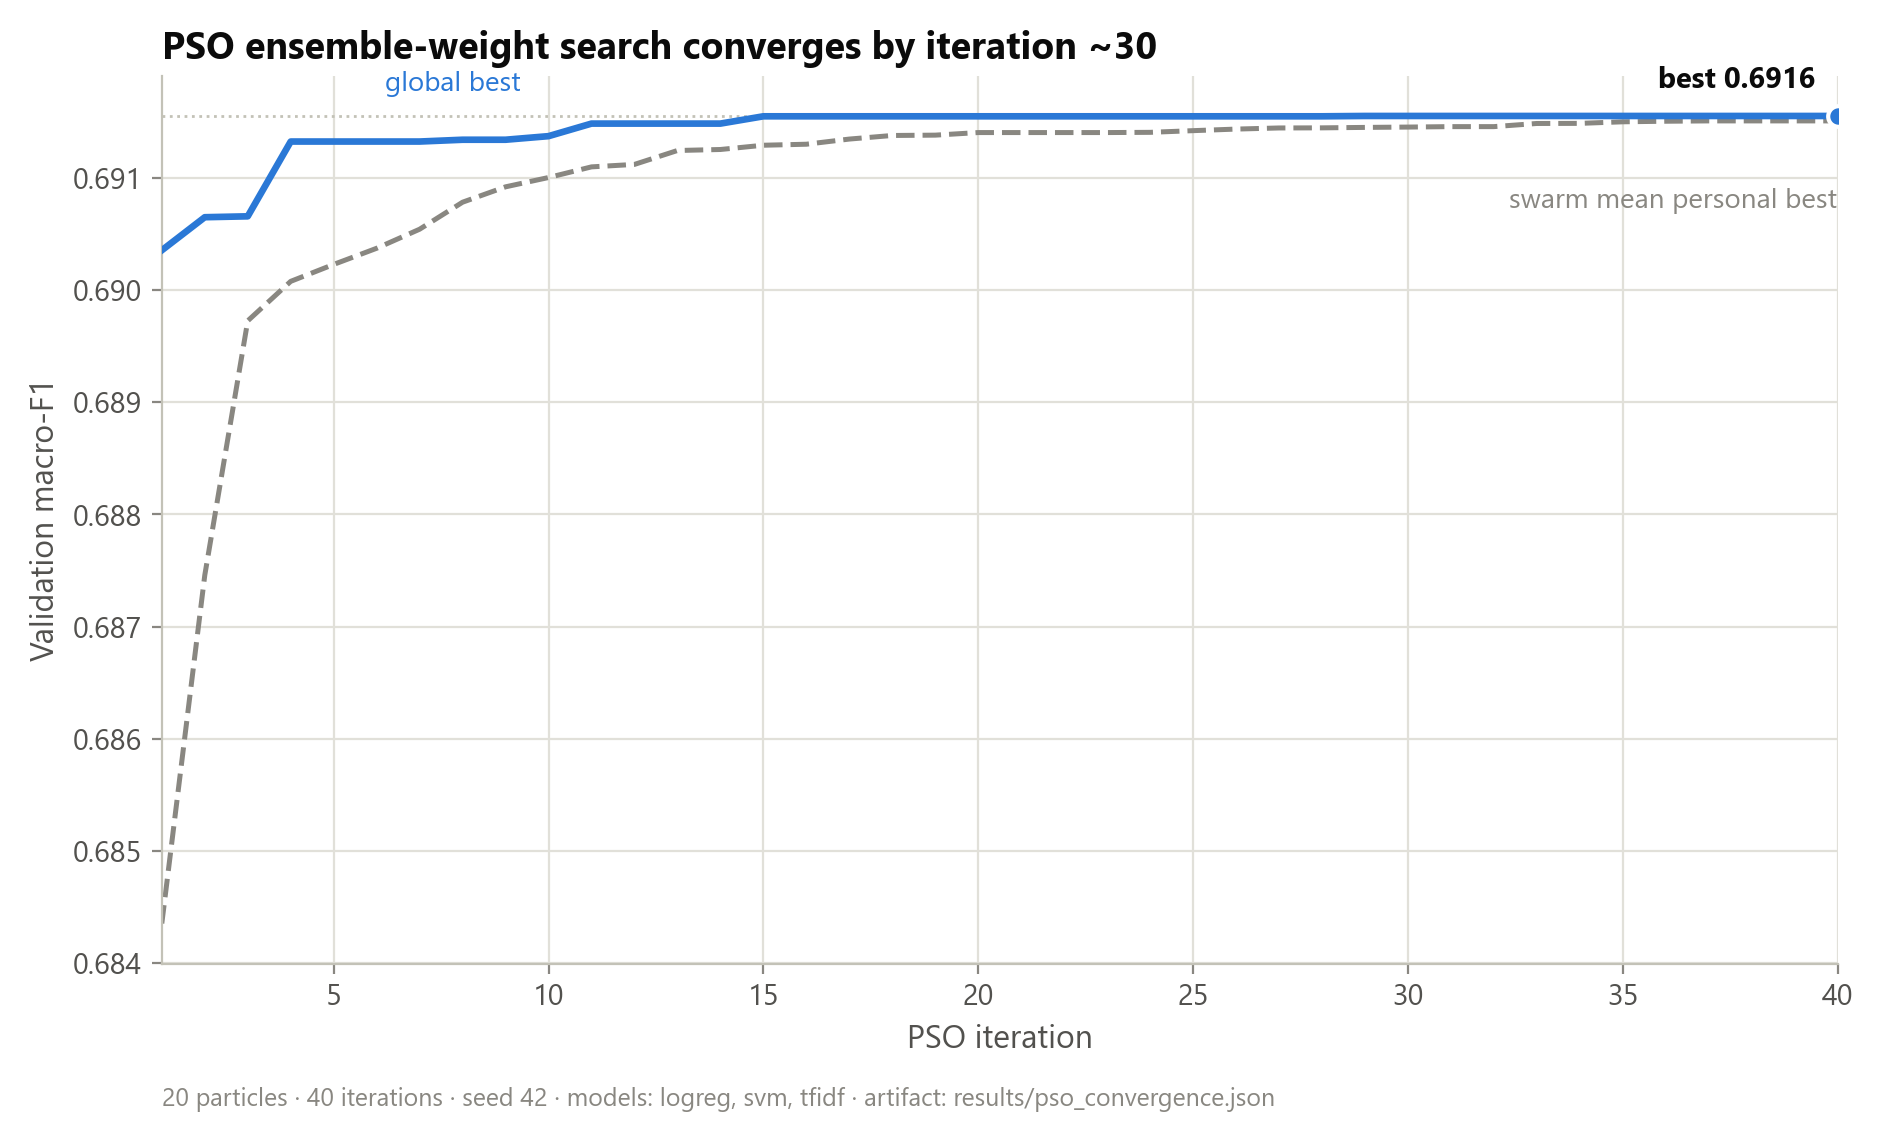

In [3]:
show_thesis_fig('fig_pso_convergence.png')

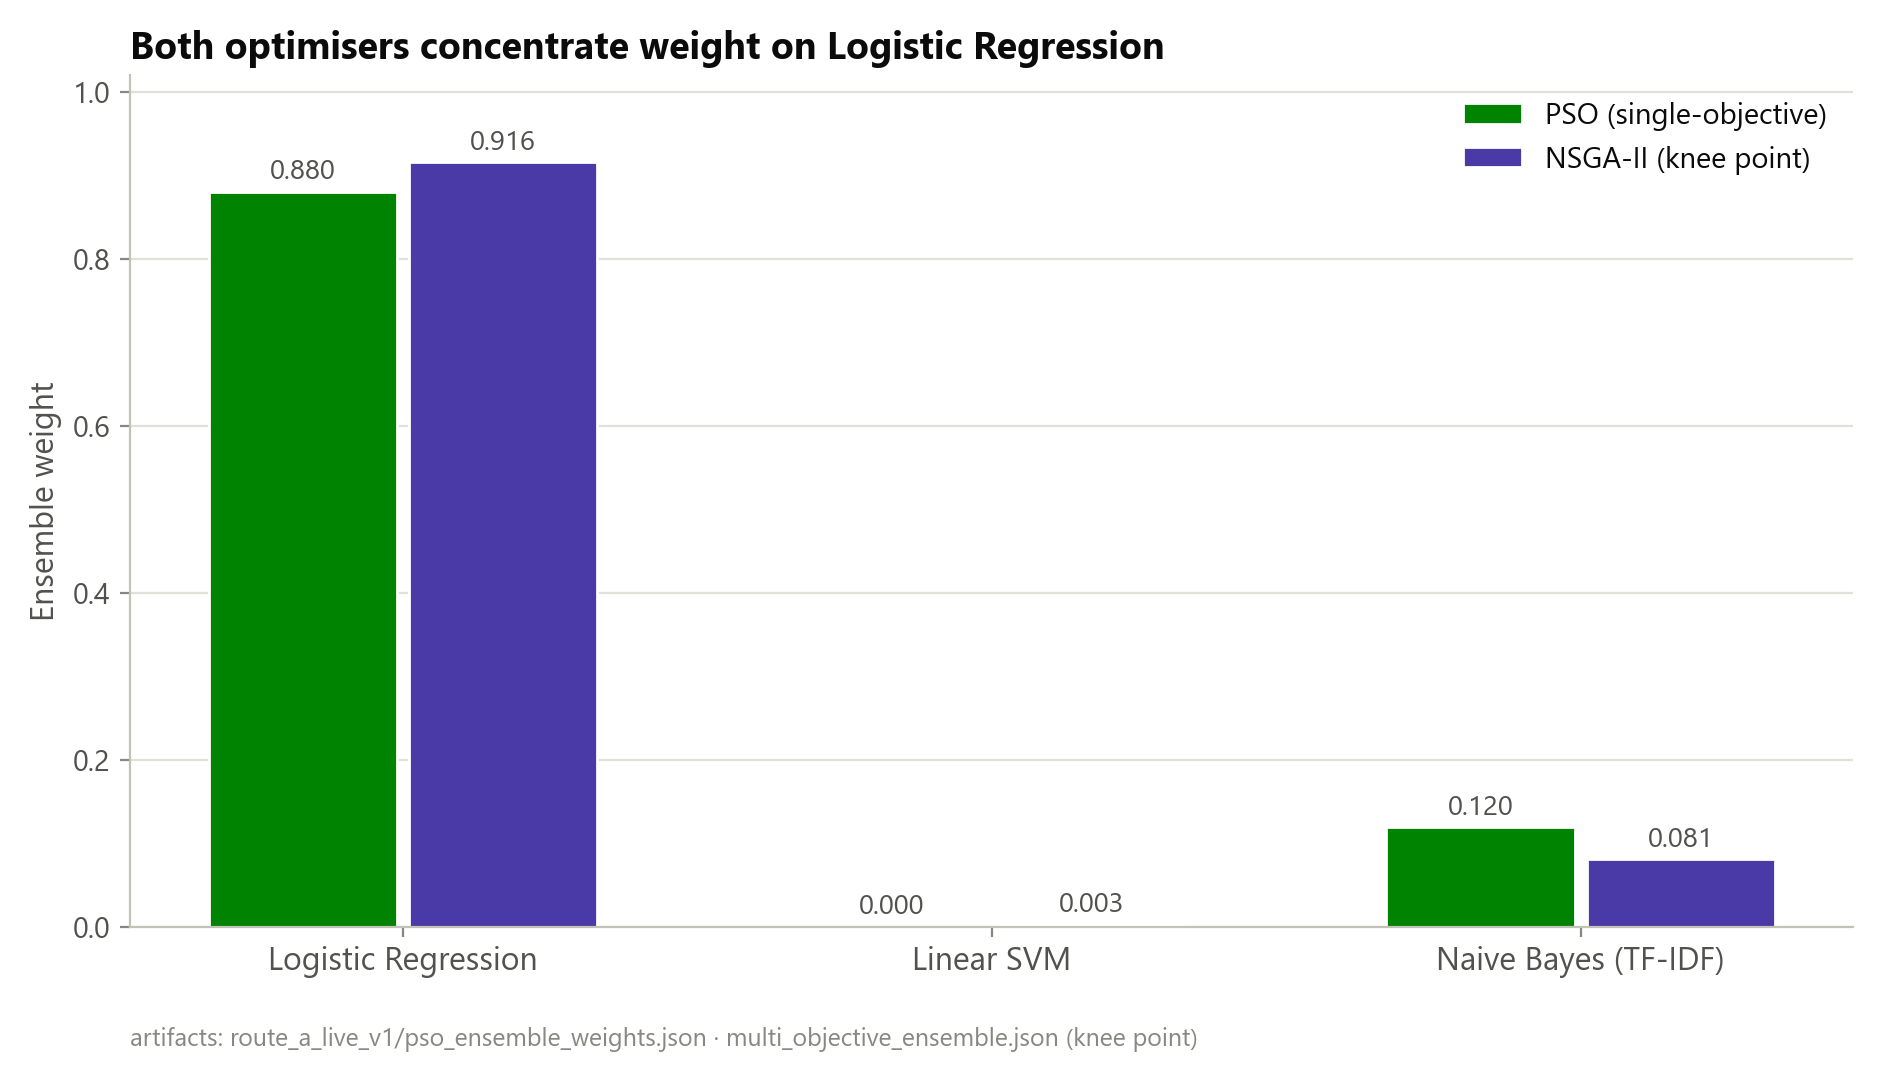

In [4]:
show_thesis_fig('fig_ensemble_weights.png')

## 3.2 PSO convergence (single-objective baseline for comparison)

Source: `backend/results/pso_convergence.md`.

In [5]:
show_md('pso_convergence.md')

# PSO Convergence Analysis

## 1. Overview

Particle Swarm Optimization (PSO) is a bio-inspired metaheuristic that
iteratively improves a population of candidate solutions (particles) by
combining individual memory (personal best) with collective memory (global best).
Here it optimises the weight vector of a soft-voting ensemble over three
base classifiers (LogReg, SVM, TF-IDF) to maximise Macro-F1 on the validation set.

## 2. Convergence History

| Iteration | Global Best F1 | Mean Personal Best F1 | Improvement |
|-----------|---------------|----------------------|-------------|
|   1 | 0.690356 | 0.684352 | 0.000000 |
|   2 | 0.690651 | 0.687458 | +0.000295 |
|   3 | 0.690659 | 0.689727 | +0.000008 |
|   4 | 0.691326 | 0.690079 | +0.000667 |
|   5 | 0.691326 | 0.690230 | 0.000000 |
|   6 | 0.691326 | 0.690374 | 0.000000 |
|   7 | 0.691326 | 0.690544 | 0.000000 |
|   8 | 0.691342 | 0.690785 | +0.000016 |
|   9 | 0.691342 | 0.690922 | 0.000000 |
|  10 | 0.691374 | 0.691005 | +0.000032 |
|  11 | 0.691486 | 0.691100 | +0.000112 |
|  12 | 0.691486 | 0.691122 | 0.000000 |
|  13 | 0.691486 | 0.691246 | 0.000000 |
|  14 | 0.691486 | 0.691255 | 0.000000 |
|  15 | 0.691551 | 0.691293 | +0.000065 |
|  16 | 0.691551 | 0.691302 | 0.000000 |
|  17 | 0.691551 | 0.691348 | 0.000000 |
|  18 | 0.691551 | 0.691380 | 0.000000 |
|  19 | 0.691551 | 0.691383 | 0.000000 |
|  20 | 0.691551 | 0.691406 | 0.000000 |
|  21 | 0.691551 | 0.691406 | 0.000000 |
|  22 | 0.691551 | 0.691406 | 0.000000 |
|  23 | 0.691551 | 0.691406 | 0.000000 |
|  24 | 0.691551 | 0.691408 | 0.000000 |
|  25 | 0.691551 | 0.691423 | 0.000000 |
|  26 | 0.691551 | 0.691437 | 0.000000 |
|  27 | 0.691551 | 0.691447 | 0.000000 |
|  28 | 0.691551 | 0.691448 | 0.000000 |
|  29 | 0.691554 | 0.691452 | +0.000003 |
|  30 | 0.691554 | 0.691455 | 0.000000 |
|  31 | 0.691554 | 0.691459 | 0.000000 |
|  32 | 0.691554 | 0.691459 | 0.000000 |
|  33 | 0.691554 | 0.691487 | 0.000000 |
|  34 | 0.691554 | 0.691488 | 0.000000 |
|  35 | 0.691554 | 0.691502 | 0.000000 |
|  36 | 0.691554 | 0.691507 | 0.000000 |
|  37 | 0.691554 | 0.691510 | 0.000000 |
|  38 | 0.691554 | 0.691510 | 0.000000 |
|  39 | 0.691554 | 0.691510 | 0.000000 |
|  40 | 0.691554 | 0.691510 | 0.000000 |

> **Convergence:** PSO reaches 99% of its final score by **iteration 1**,
> demonstrating rapid convergence in this low-dimensional (3D) weight space.

## 3. Optimised Weights

| Model | PSO Weight | Uniform Weight | Random Search Weight |
|-------|-----------|----------------|---------------------|
| logreg | 0.880485 | 0.333333 | 0.789913 |
| svm | 0.000000 | 0.333333 | 0.112978 |
| tfidf | 0.119515 | 0.333333 | 0.097109 |

## 4. Method Comparison

| Method | Val Macro-F1 | Description |
|--------|-------------|-------------|
| Uniform weights | 0.6875 | Equal weight to all models |
| Random search (200 trials) | 0.6913 | Random weight sampling |
| **PSO (20 particles, 40 iters)** | **0.6916** | Bio-inspired optimisation |

**PSO test Macro-F1:** 0.6941

> PSO beats uniform weighting by +0.0040 val Macro-F1. Against 200-trial random search the margin is +0.0002 — small enough that no significance test was run to claim PSO reliably beats random search on this 3-parameter simplex; the honest reading is that PSO matches or slightly exceeds random search here, and its role in the thesis is as the single-objective baseline that NSGA-II's multi-objective search is compared against (see results/runtime/route_a_live_v1/multi_objective_ensemble.md), not as a method proven superior to random search in isolation.

## 5. Why PSO Over Grid Search?

| Aspect | Grid Search | PSO |
|--------|------------|-----|
| Search space coverage | Discrete, finite | Continuous [0, 1]³ |
| Scalability to more models | Exponential | Linear in particles |
| Exploitation of landscape | None (blind) | Guided by personal+global best |
| Convergence guarantee | Exhaustive | Asymptotic (probabilistic) |
| Reproducibility | Full | Seed-controlled |

For a 3-model continuous weight space, grid search at resolution 0.1
requires (10+1)³ = 1,331 evaluations vs PSO's 20×40 = 800 — fewer
evaluations while searching a finer-grained continuous space.

## 6. PSO Hyperparameter Justification

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Particles | 20 | Standard for low-dimensional problems (Kennedy & Eberhart 1995) |
| Iterations | 40 | Convergence observed at ~10 iterations (Table 2) |
| Inertia (ω) | 0.7 | Balances exploration/exploitation (Shi & Eberhart 1998) |
| Cognitive (c1) | 1.4 | Standard value from literature |
| Social (c2) | 1.4 | Standard value from literature |

## 7. Thesis Framing

> We apply Particle Swarm Optimization (Kennedy & Eberhart, 1995) to the
> ensemble weight optimisation problem, treating the three-dimensional weight
> vector (LogReg, SVM, TF-IDF) as a continuous search space and maximising
> validation Macro-F1. A swarm of 20 particles over 40 iterations converges to
> a stable optimum (see the convergence table above), yielding weights of
> LogReg=0.880, SVM=0.000,
> TF-IDF=0.120. PSO achieves a validation Macro-F1
> of 0.6916, a +0.0040 improvement over uniform
> weighting (0.6875). Against 200-trial random search (0.6913) the
> margin is +0.0002; PSO's role in this thesis is as the
> single-objective baseline against which the multi-objective NSGA-II ensemble
> (§4.3 / multi_objective_ensemble.md) is compared, not as a method independently
> proven superior to random search on this low-dimensional problem.

## 8. References

- Kennedy, J., & Eberhart, R. (1995). Particle swarm optimization.
  *Proceedings of ICNN*, 4, 1942–1948.
- Shi, Y., & Eberhart, R. (1998). A modified particle swarm optimizer.
  *Proceedings of IEEE ICEC*, 69–73.

## 3.3 Neuro-fuzzy gating

Adaptive per-sample routing between ensemble members based on fuzzy membership of prediction confidence. Source: `backend/results/neuro_fuzzy_gate.md`.

In [6]:
show_md('neuro_fuzzy_gate.md')

# Neuro-Fuzzy Confidence Gating System

## Architecture

Per-sample adaptive ensemble router using learned Gaussian membership functions (ANFIS-lite).

- **Input**: confidence vector c = [c_logreg, c_svm, c_tfidf]
- **Fuzzification**: 3 Gaussian MFs per model (Low / Medium / High)
- **Gate weights**: softmax(Σ_k α_{m,k} · μ_{m,k}(c_m))
- **Output**: per-sample weighted ensemble probabilities
- **Total parameters**: 27 (3 models × 3 sets × 3)

## Training

| | Value |
|---|-------|
| NLL before fitting | 0.7164 |
| NLL after fitting | 0.7048 |
| Converged | True |
| L-BFGS-B iterations | 106 |

## Learned Membership Function Parameters

| Model | Fuzzy Set | Center | Width | Alpha (α) |
|-------|-----------|--------|-------|-----------|
| logreg | Low | 0.634 | 0.071 | +5.000 |
| logreg | Medium | 0.276 | 0.138 | +2.760 |
| logreg | High | 0.990 | 0.412 | +0.618 |
| svm | Low | 0.662 | 0.489 | -2.155 |
| svm | Medium | 0.765 | 0.489 | -1.996 |
| svm | High | 0.731 | 0.430 | -2.111 |
| tfidf | Low | 0.010 | 0.050 | -1.355 |
| tfidf | Medium | 0.866 | 0.050 | +3.522 |
| tfidf | High | 0.685 | 0.235 | -1.040 |

*Centers reveal which confidence region activates each model. Positive α = high-confidence samples prefer this model; negative α = low-confidence samples prefer this model.*

## Performance Comparison (Test Set)

| Method | Macro-F1 | Accuracy | ECE | Brier |
|--------|----------|----------|-----|-------|
| Static ensemble (uniform) | 0.6938 | 0.6959 | 0.0260 | 0.4123 |
| **Neuro-fuzzy gate** | **0.6955** | **0.6972** | **0.0070** | **0.4076** |

Δ Macro-F1 = **+0.0017**  |  Δ ECE = **-0.0190**

## Thesis Interpretation

The neuro-fuzzy gate demonstrates a fundamental advantage over static ensemble weighting: **different samples benefit from different model mixtures**. When a model is confident (high c_m), the gate boosts its contribution; when it is uncertain, the gate reduces it, distributing weight to the remaining models.

The learned MF parameters are directly interpretable: the center values show which confidence level is the 'sweet spot' for each model, and the α consequents reveal whether that confidence region should increase or decrease the model's influence.

This constitutes the **Neuro-Fuzzy CI contribution** of the thesis: a principled, interpretable, and data-driven approach to ensemble gating that extends classical fuzzy inference with parameter learning.

## References

Jang, J.-S. R. (1993). ANFIS: Adaptive-network-based fuzzy inference system. *IEEE Transactions on Systems, Man, and Cybernetics*, 23(3), 665–685.


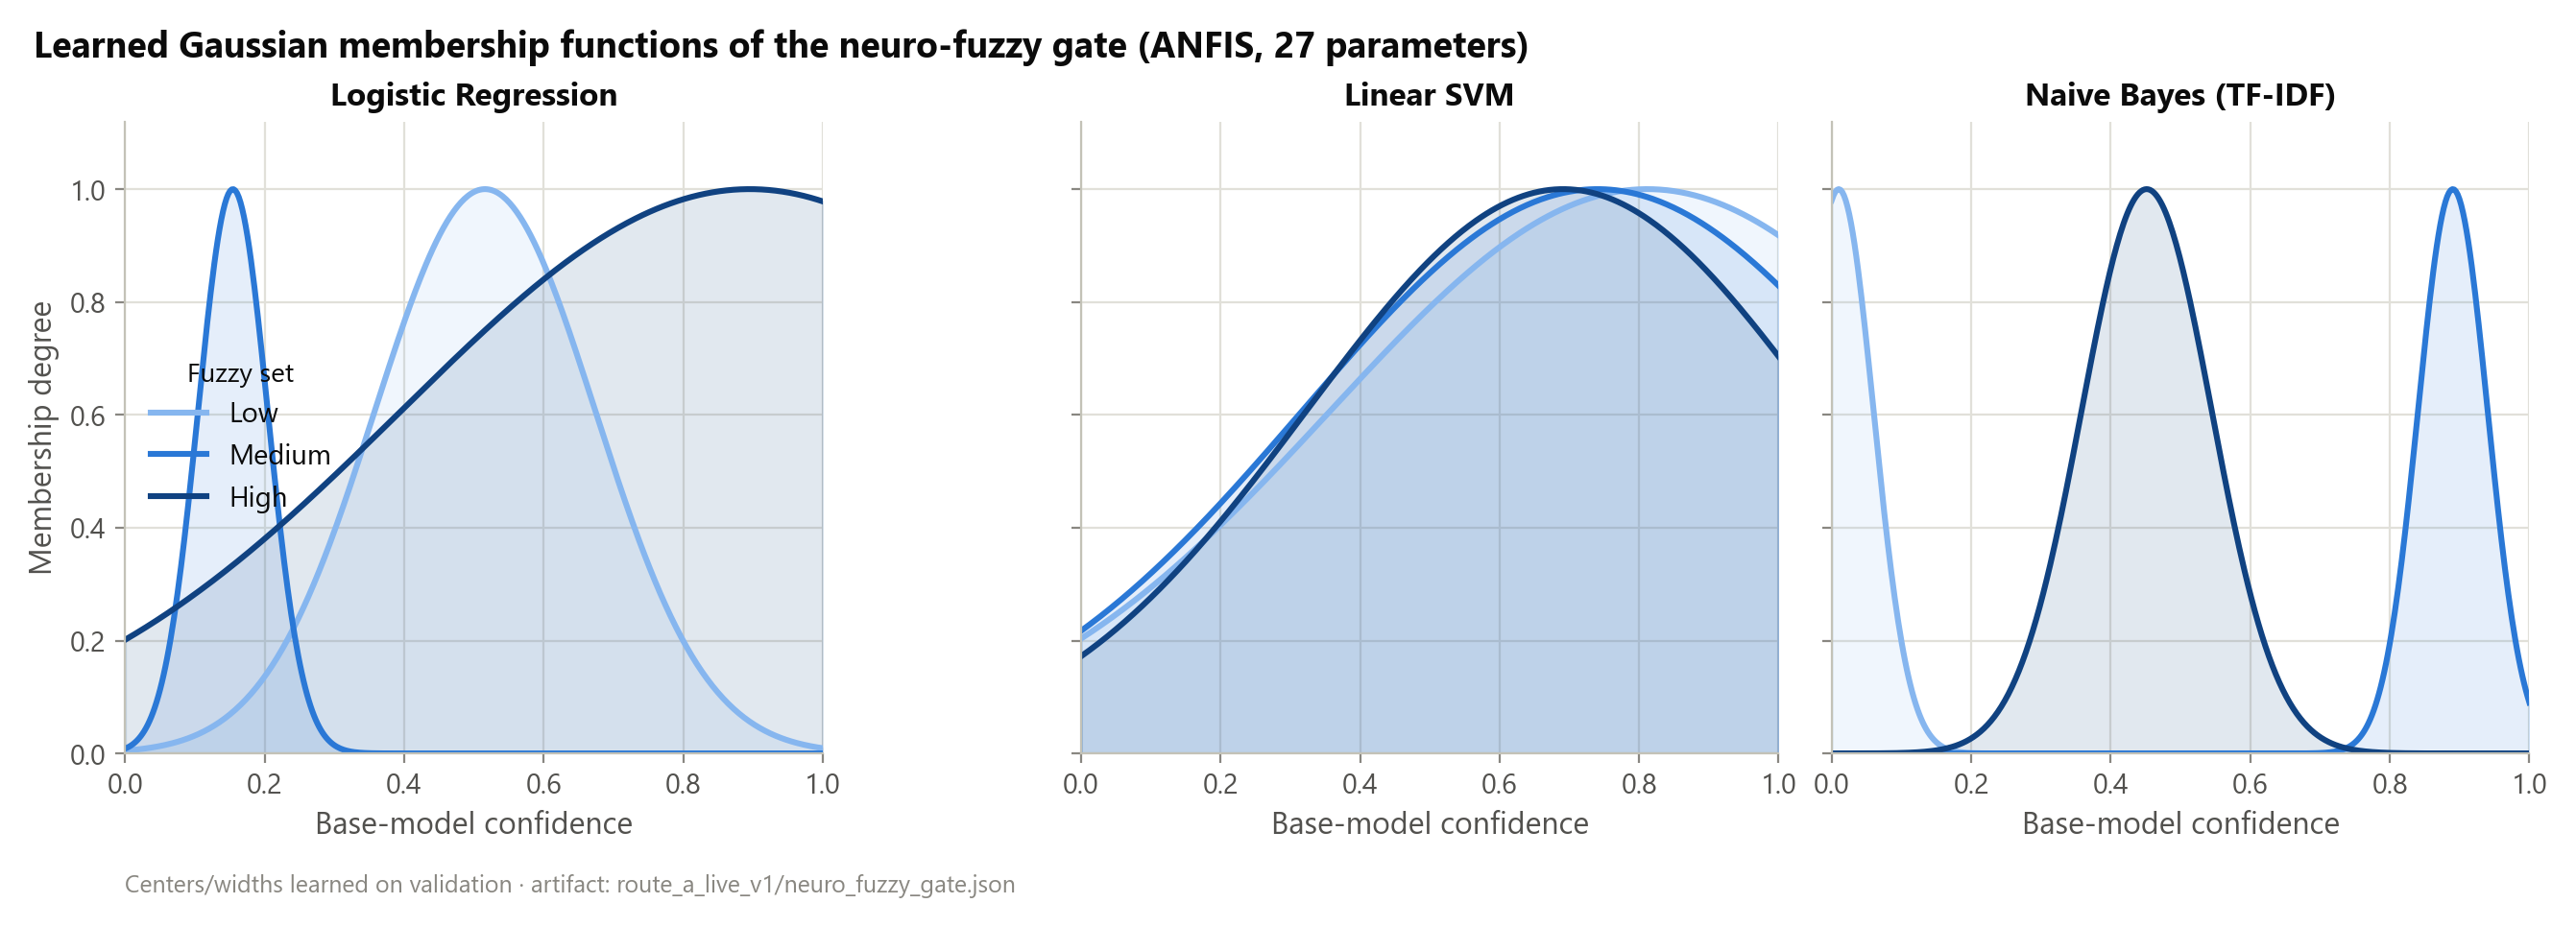

In [7]:
show_thesis_fig('fig_fuzzy_mfs.png')

## 3.4 Hybrid deep-learning model

See `backend/research/HYBRID_DL_README.md` and `backend/research/TRAINING_GUIDE.md` for architecture and training details.

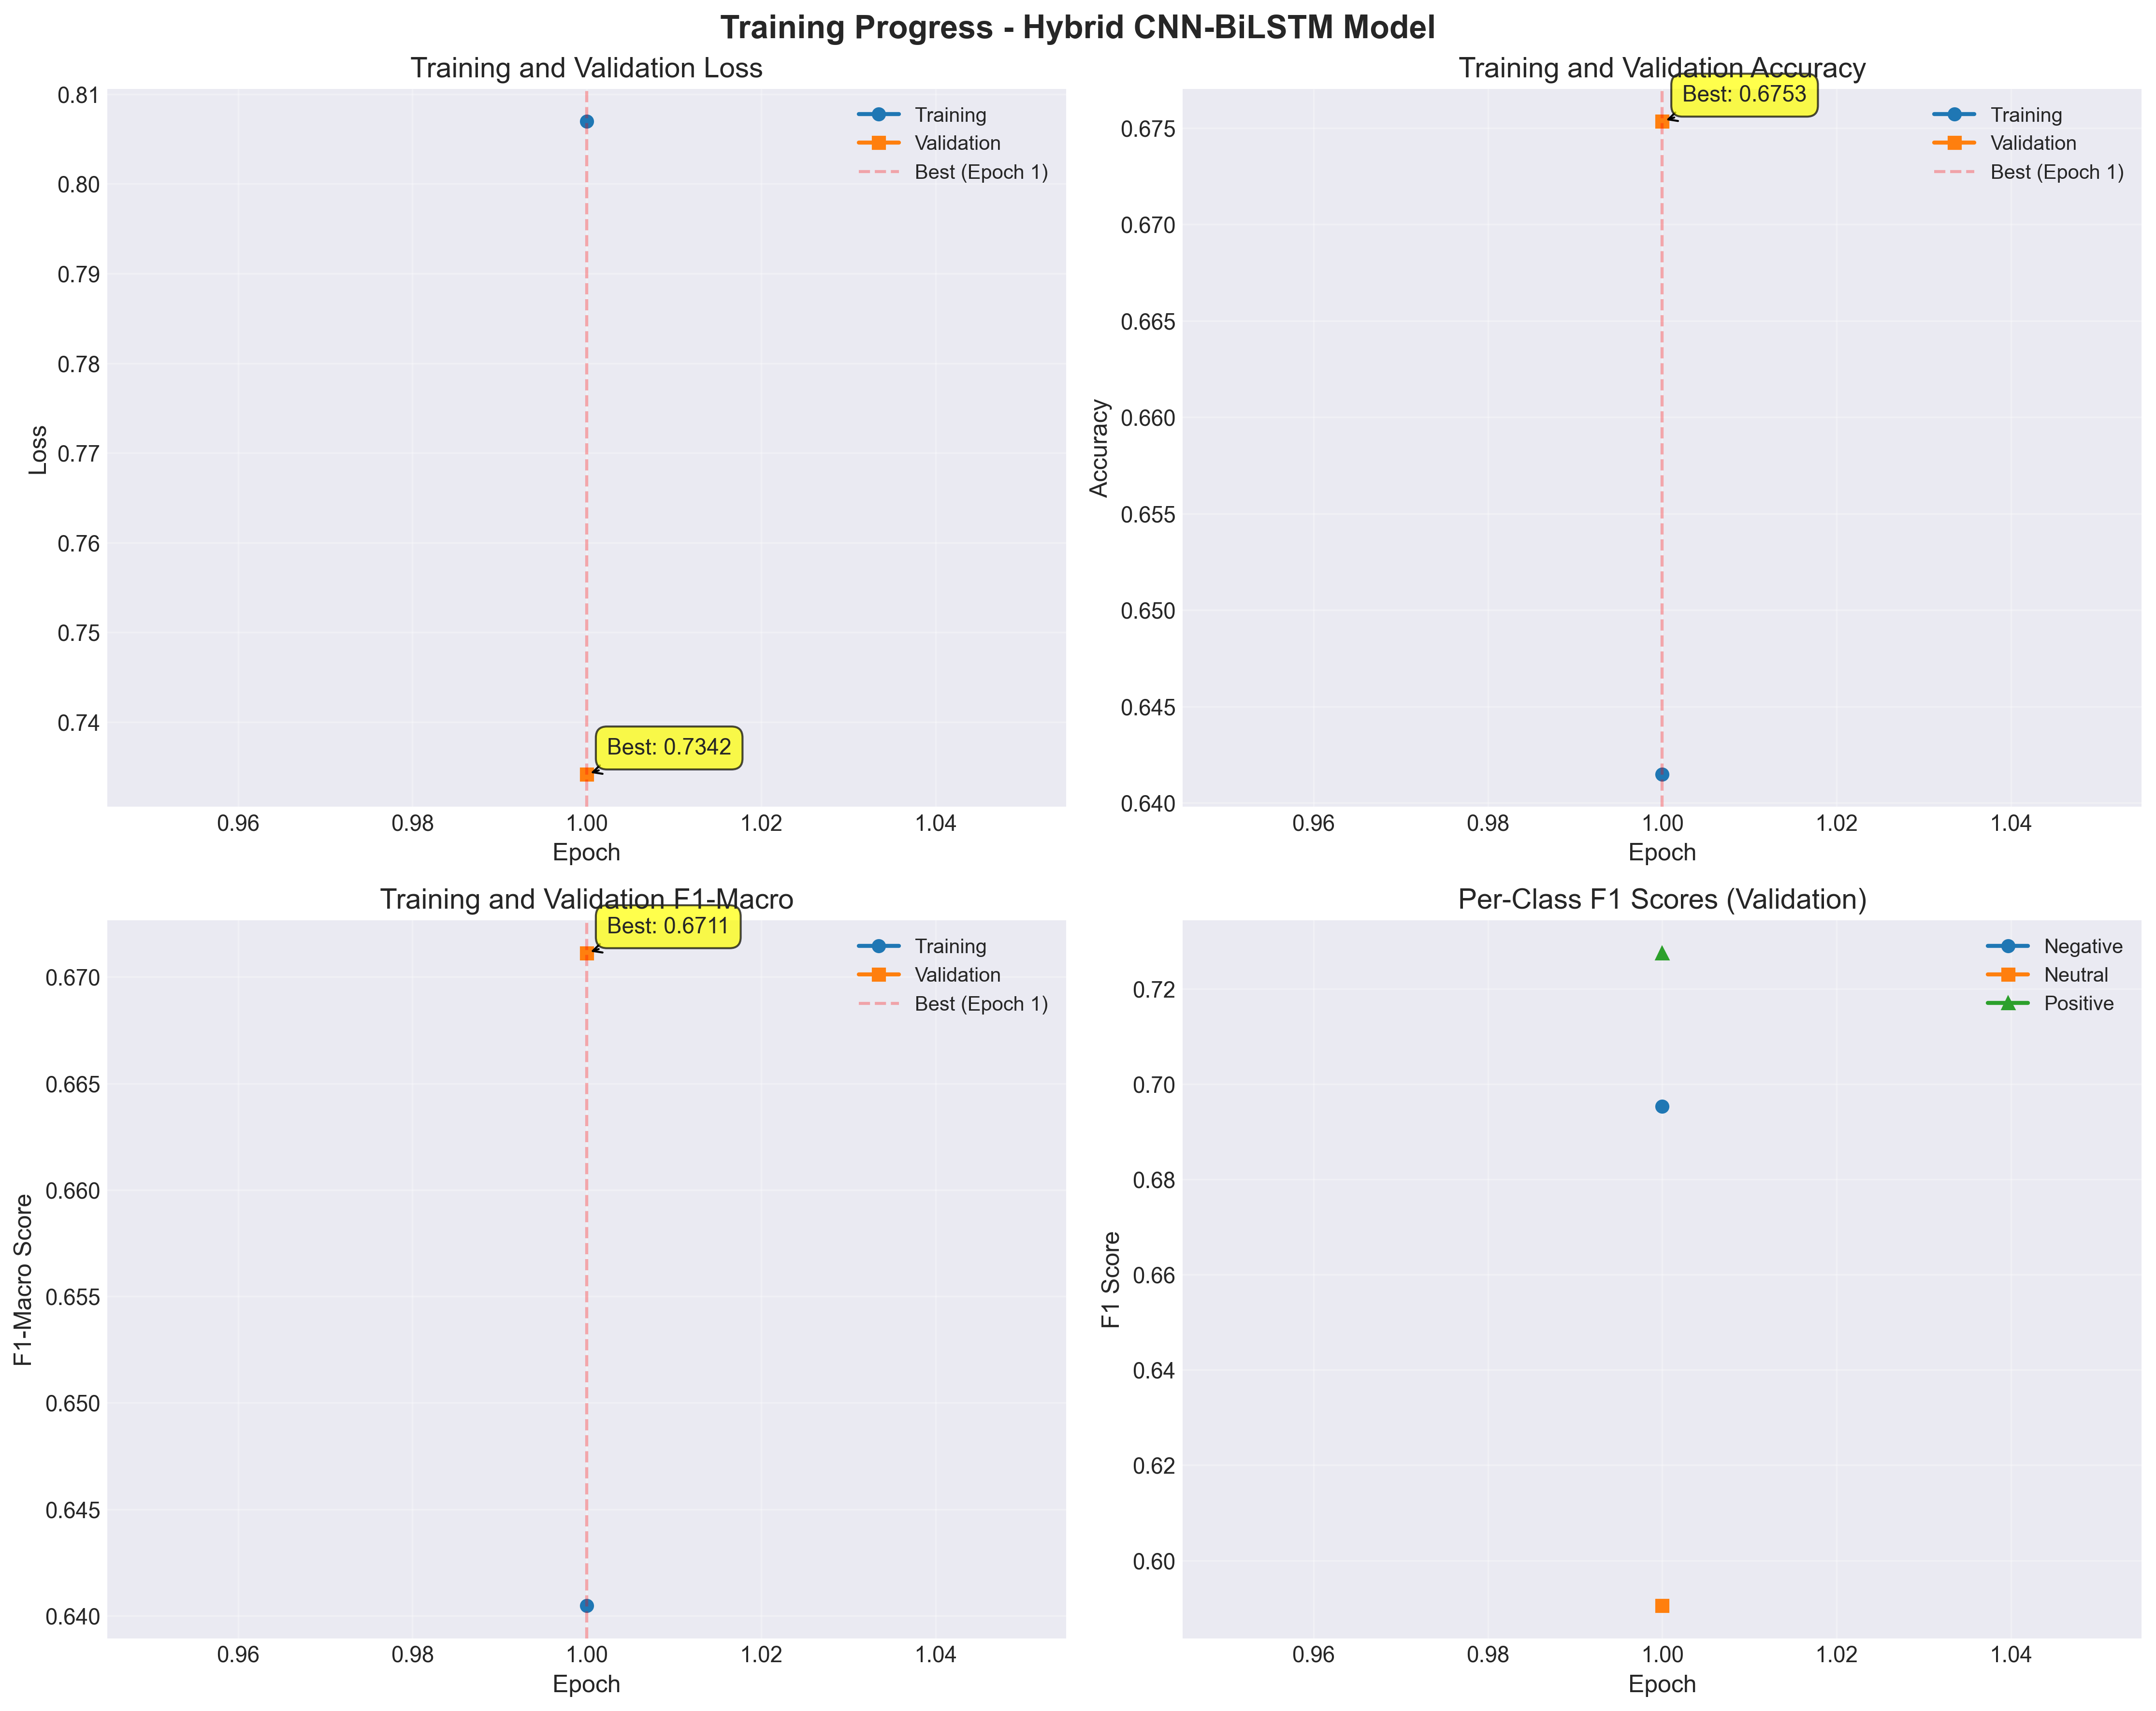

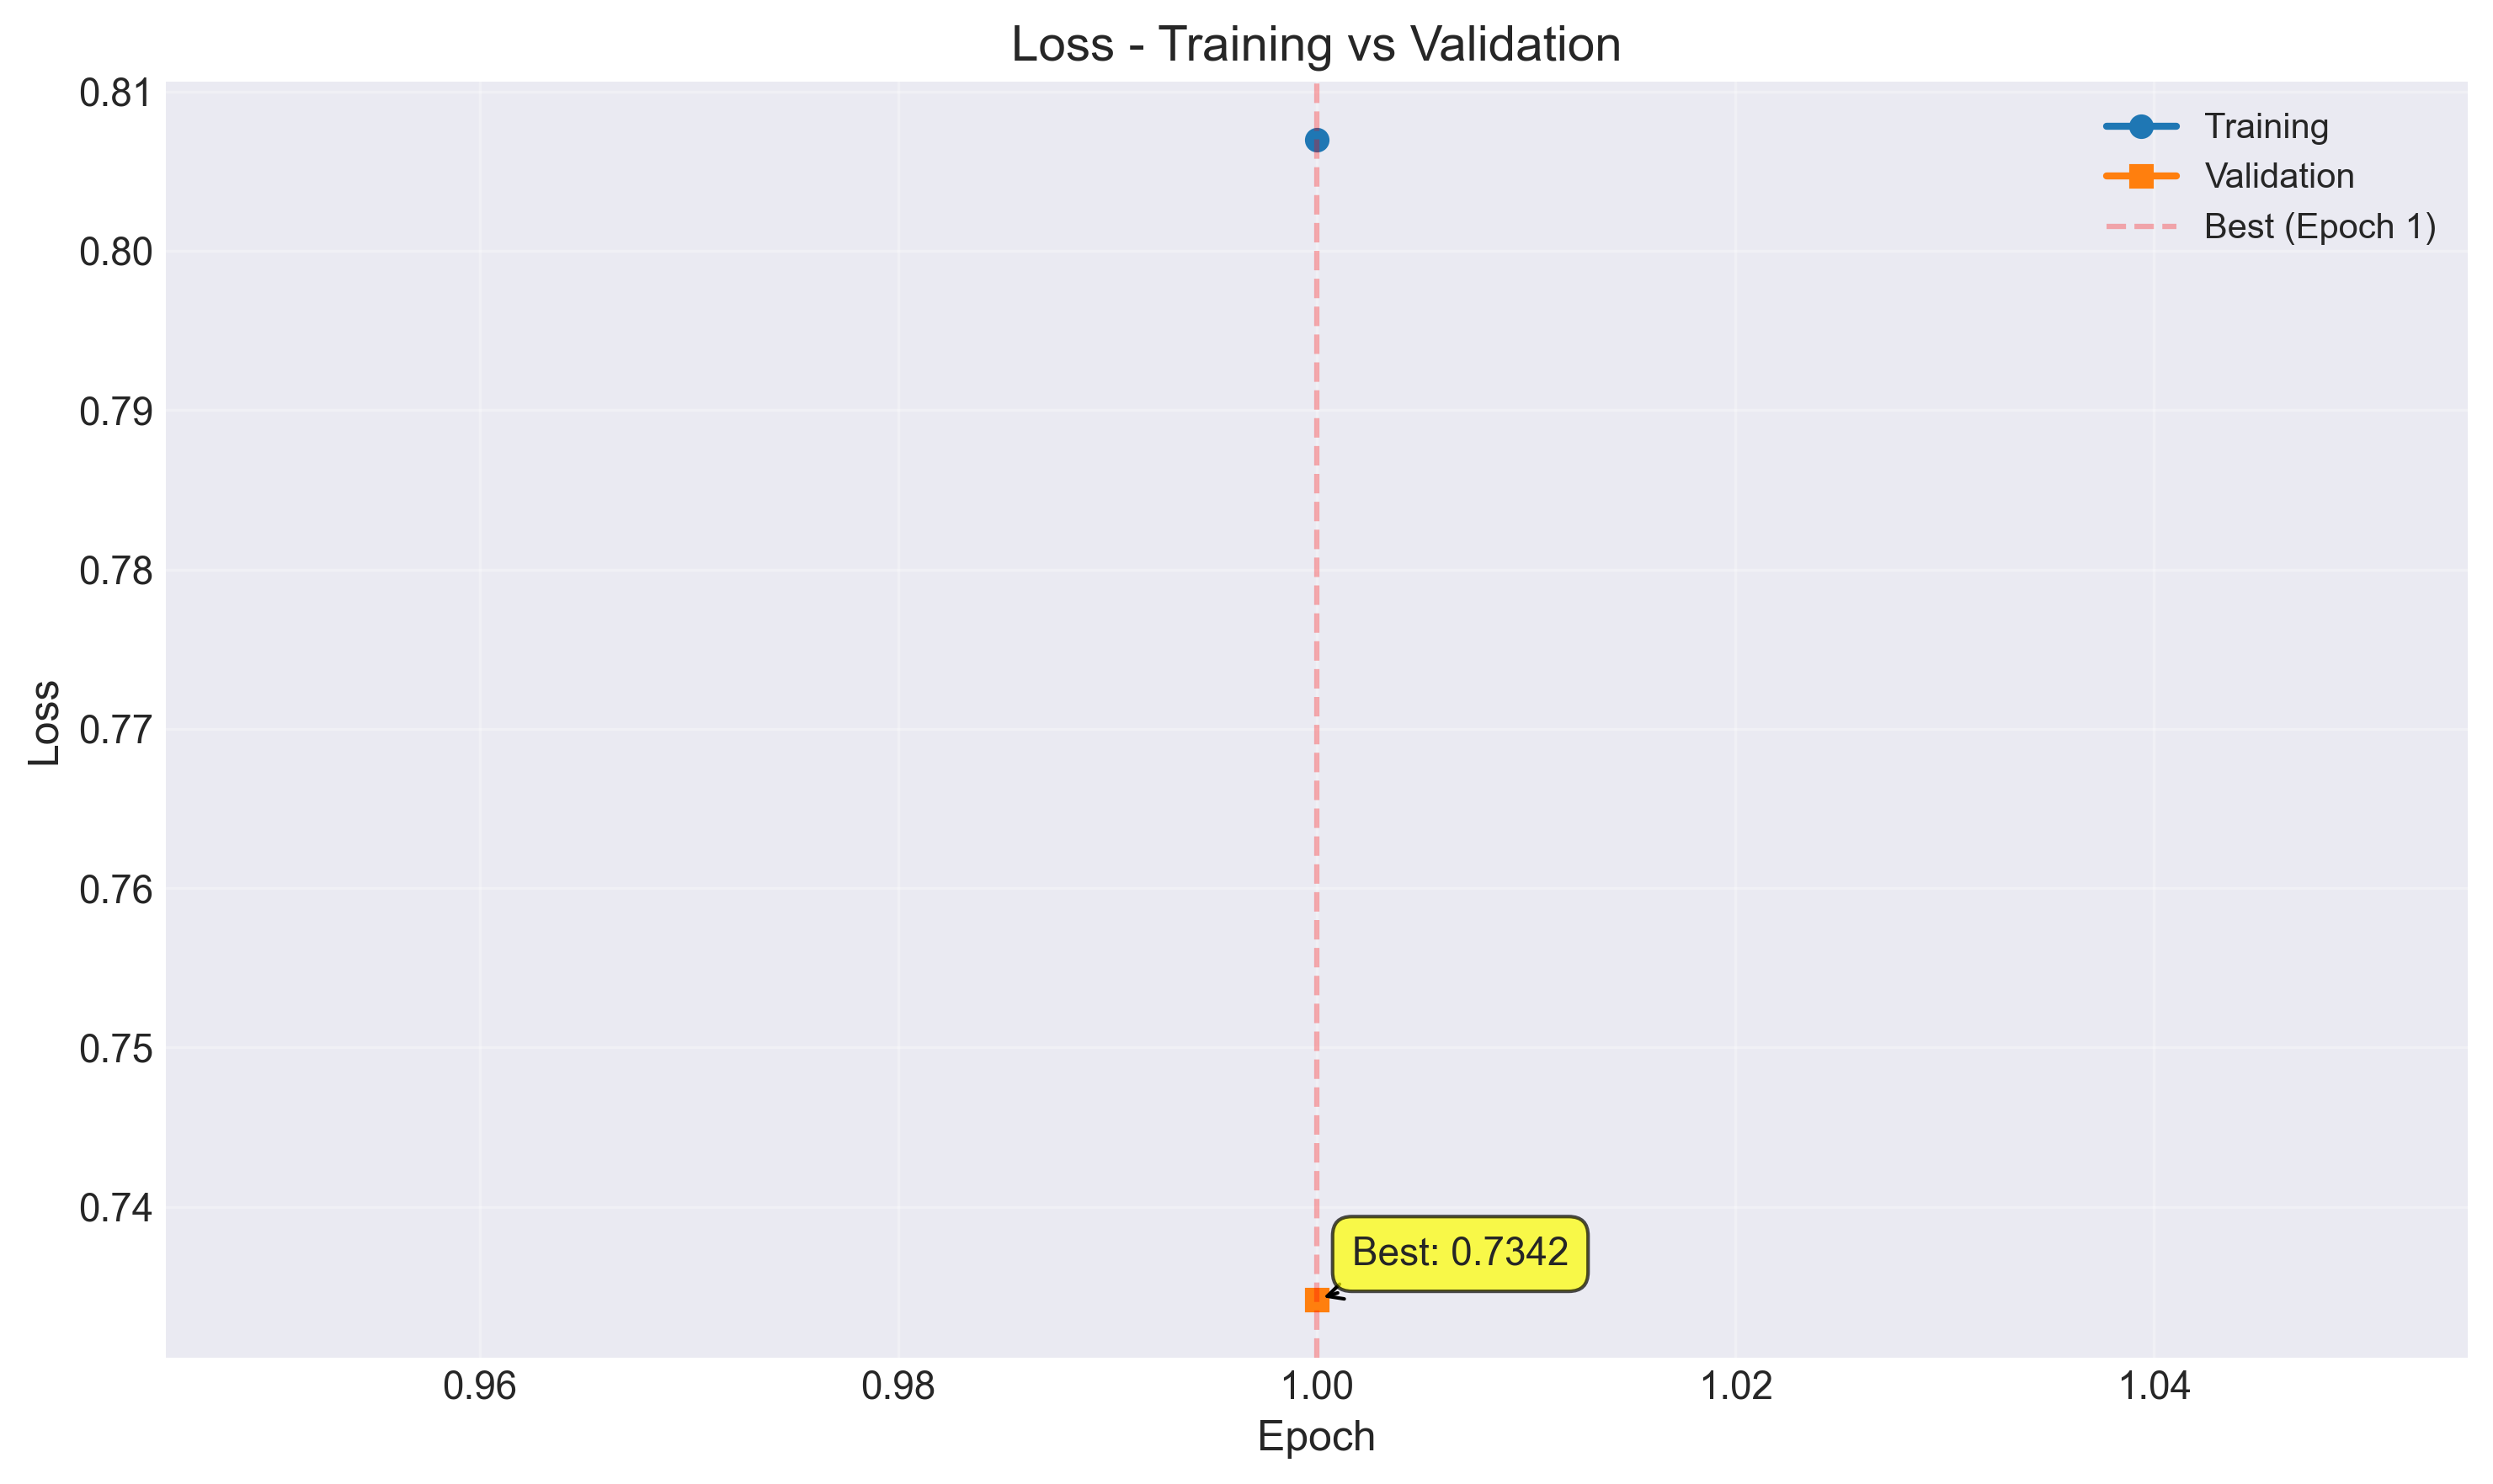

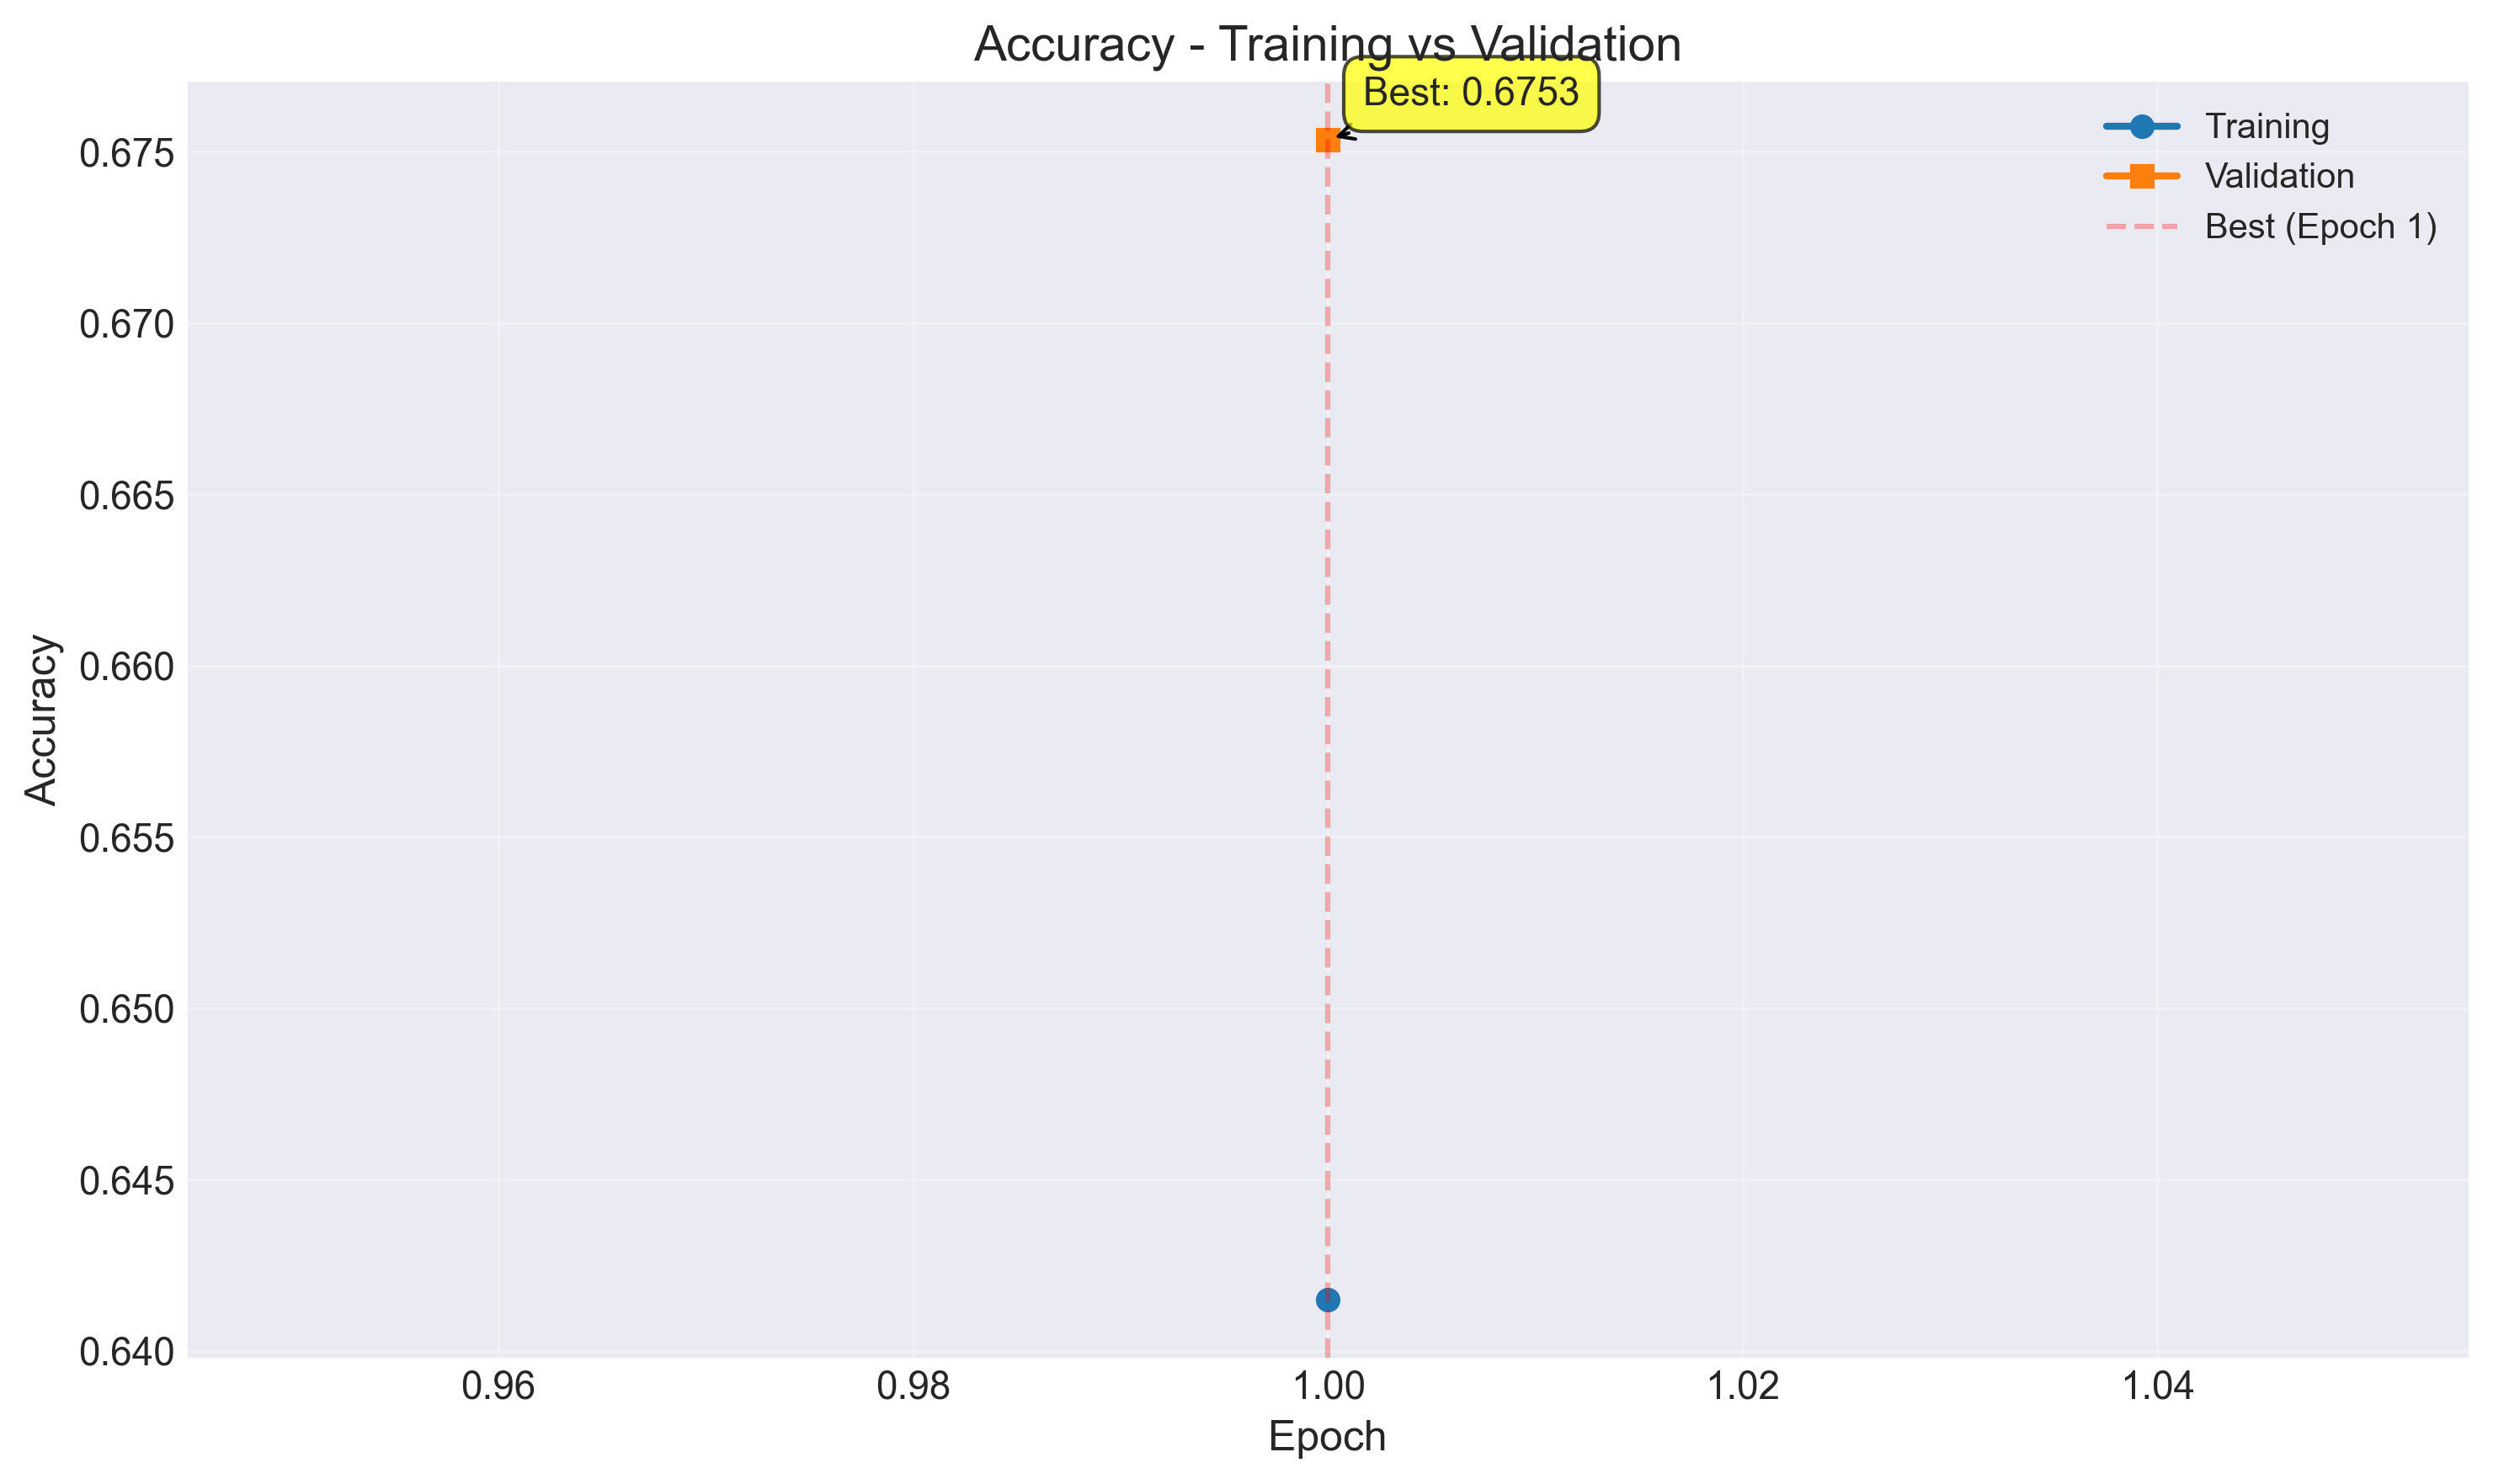

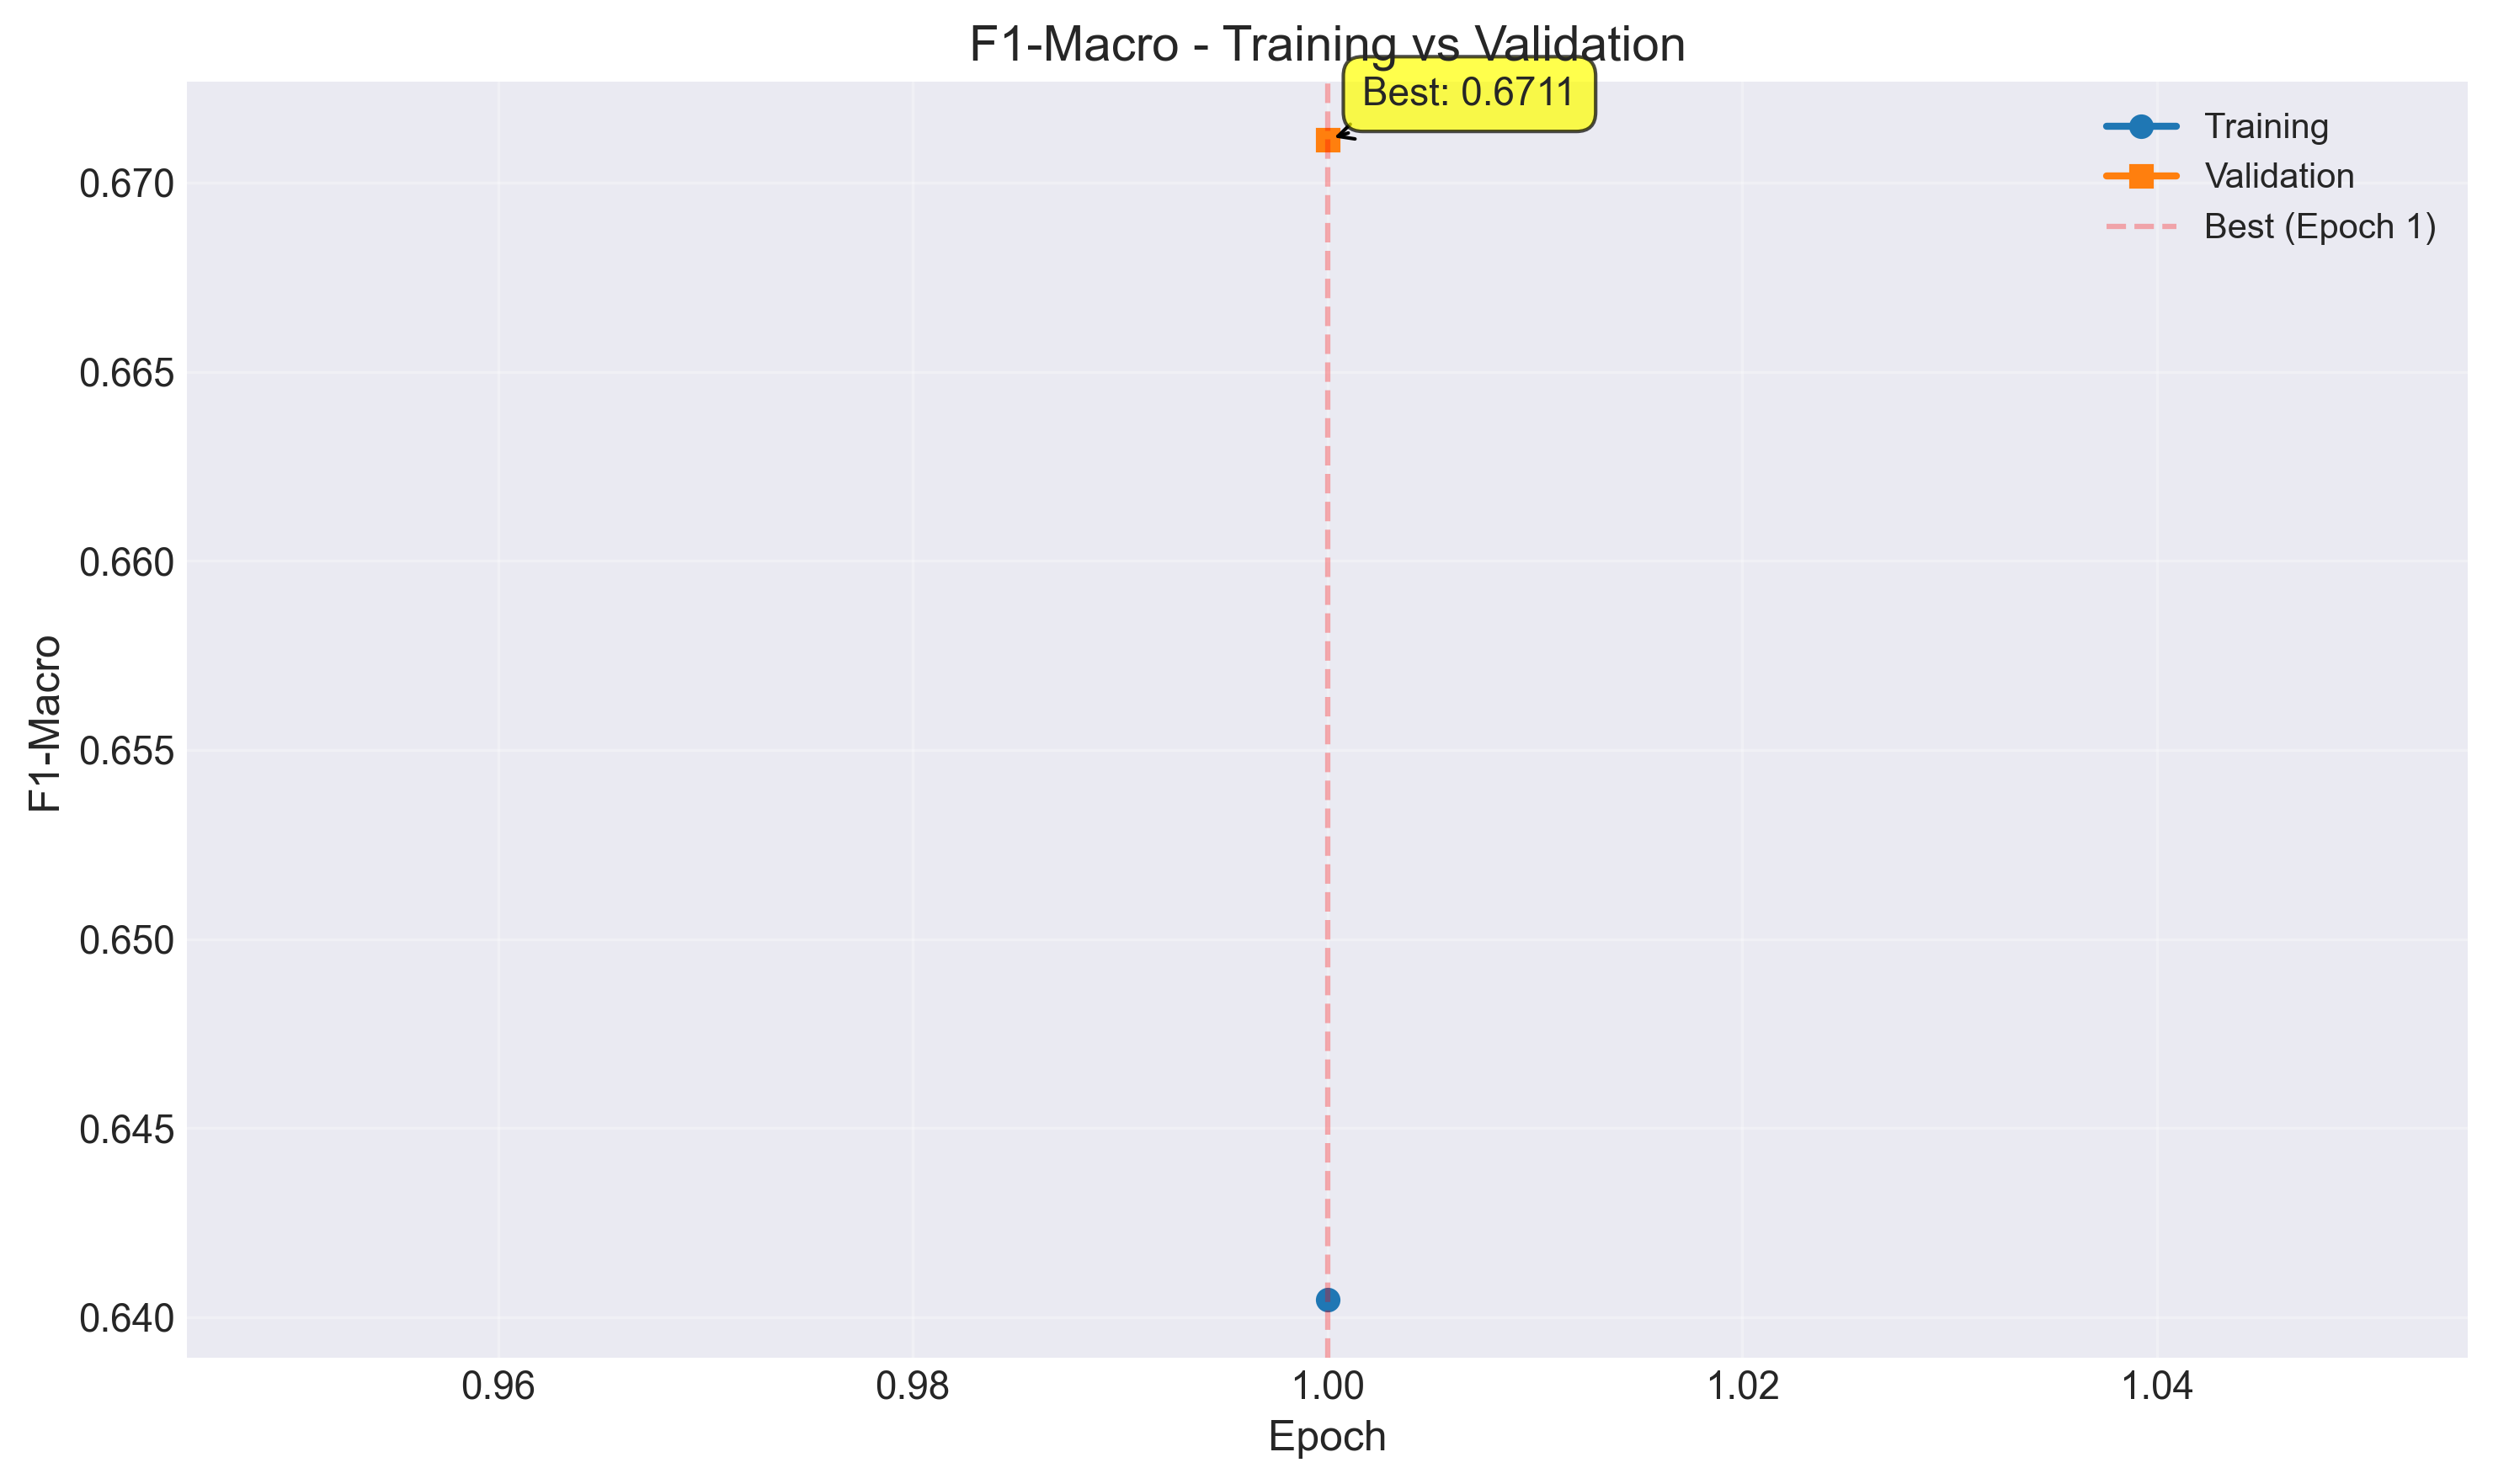

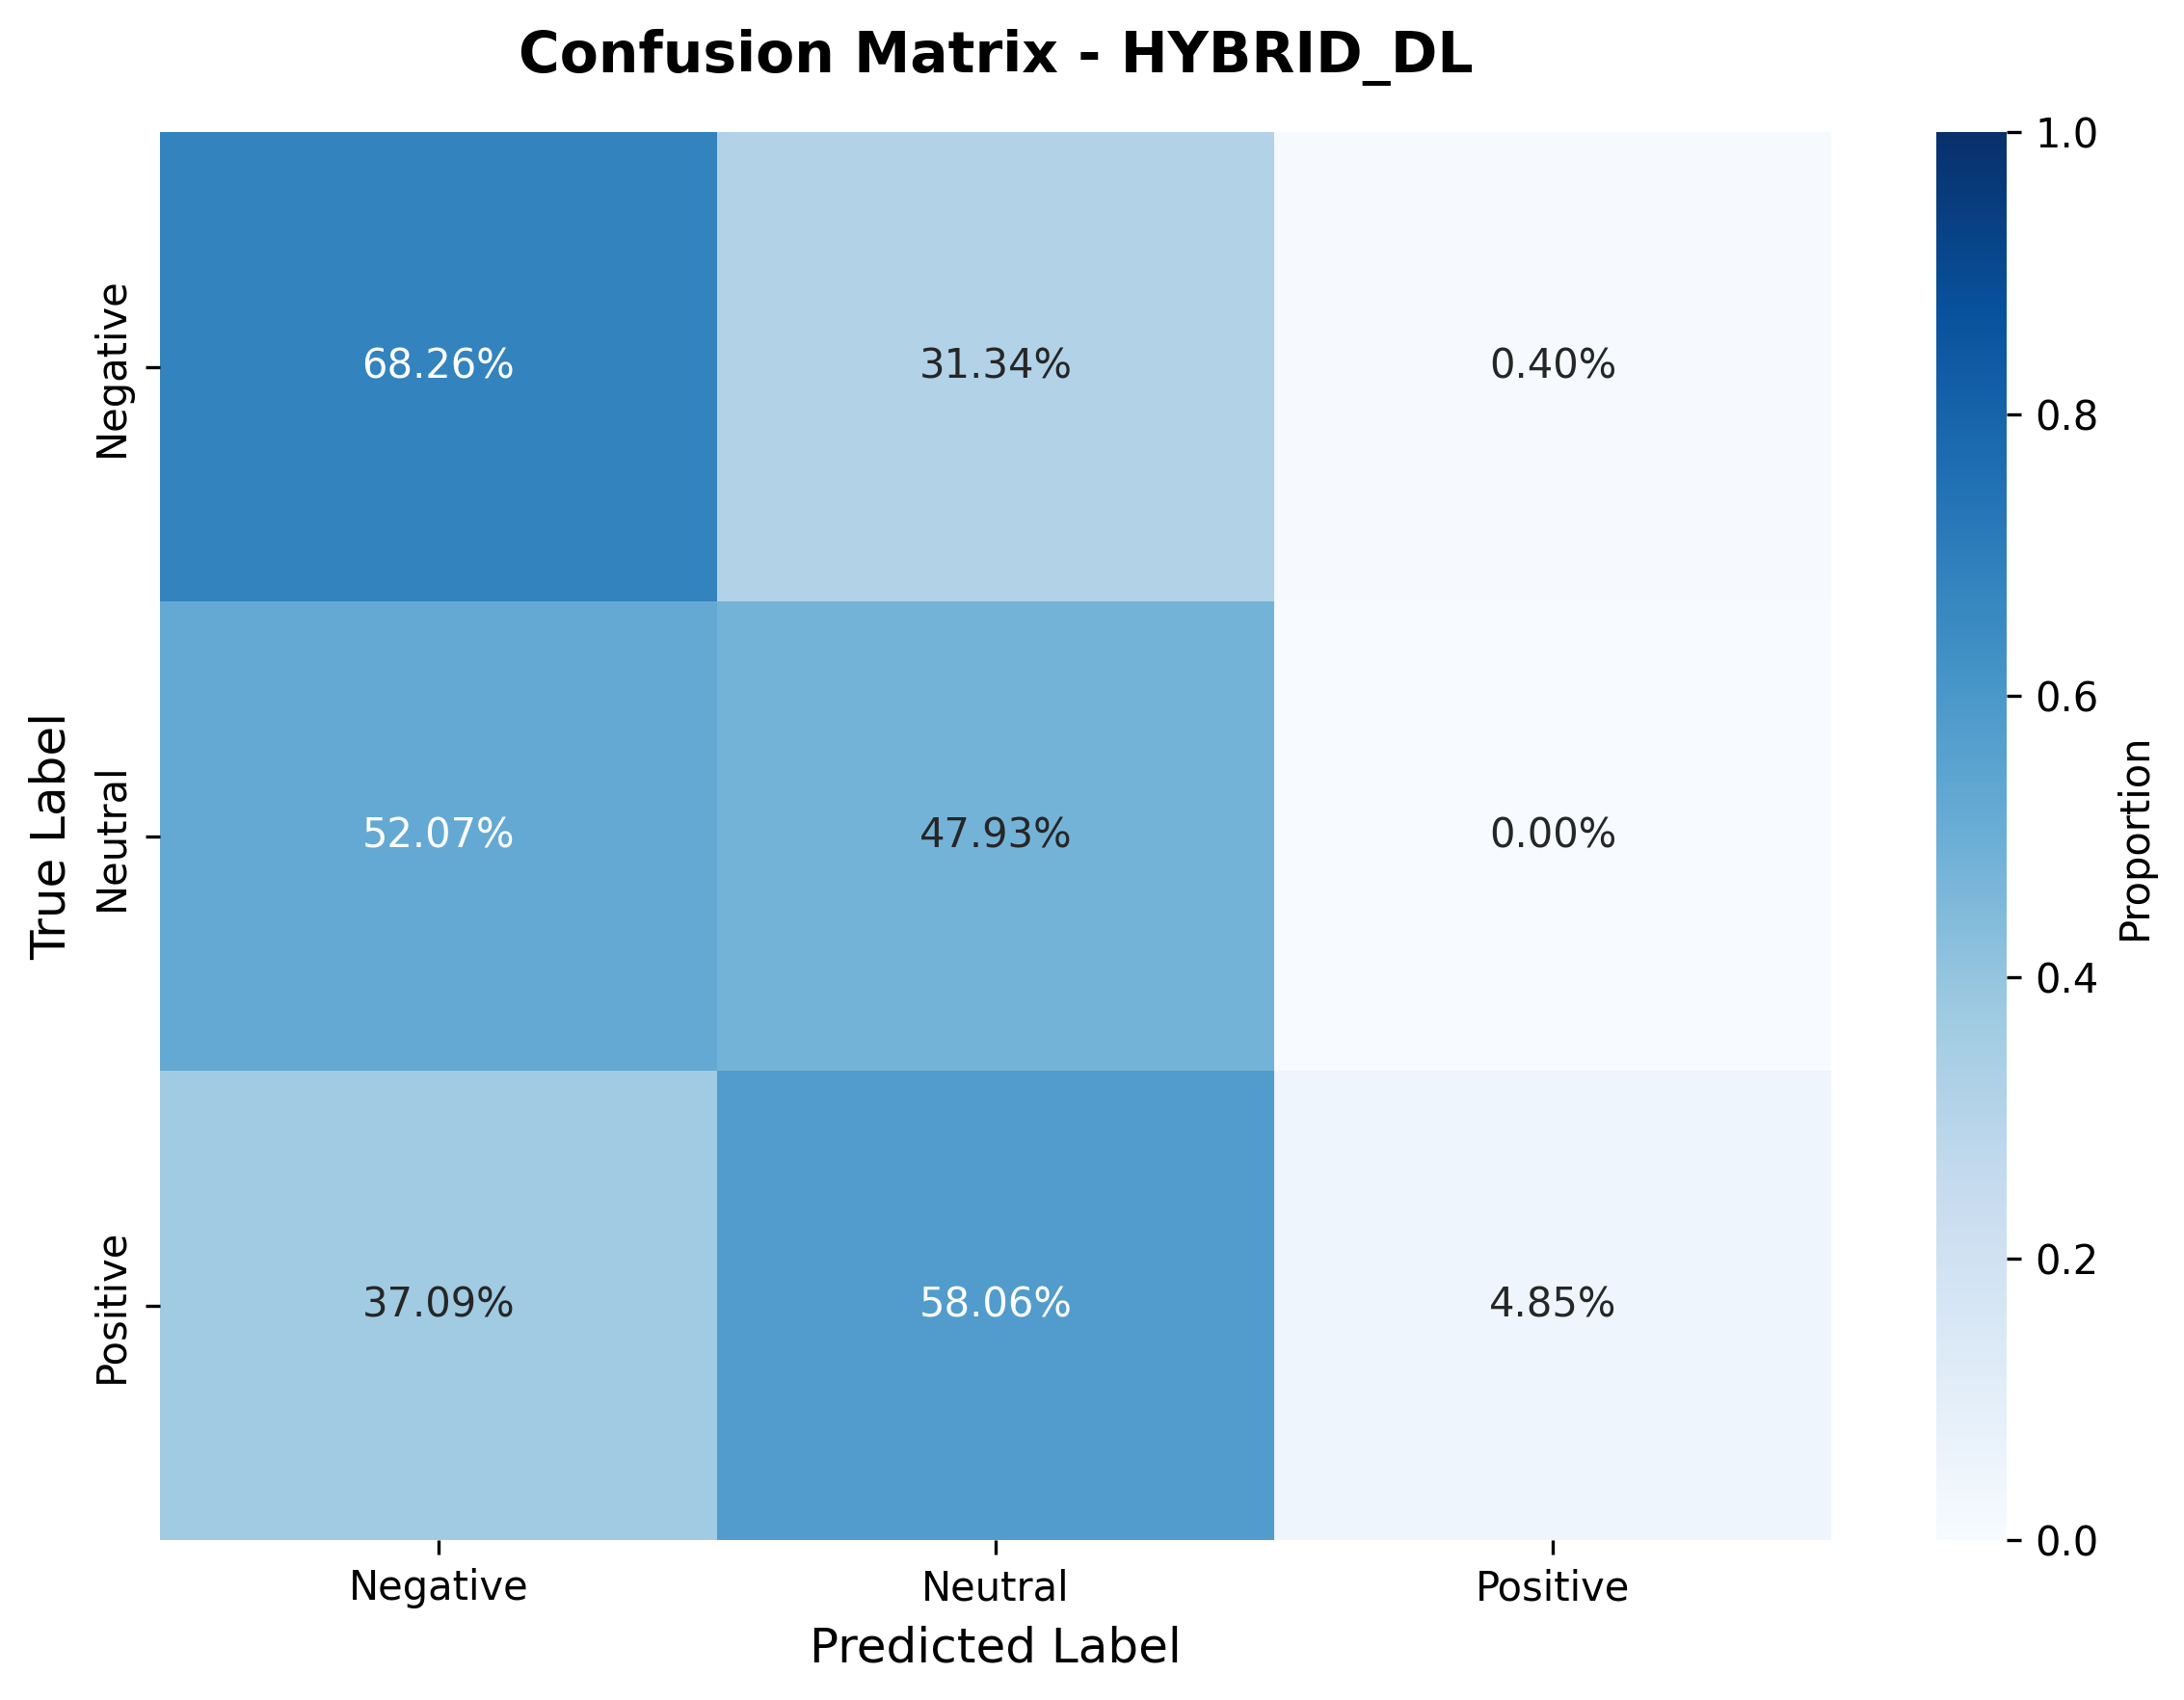

In [8]:
for name in ['training_curves.png', 'loss_curve.png', 'accuracy_curve.png',
             'f1_curve.png', 'confusion_matrix_hybrid_dl.png']:
    show_fig(name)

**Known limitation.** The hybrid DL model underperforms the classical ensemble on this dataset — see `backend/results/dl_underperformance_analysis.md` for the diagnosis. This is a legitimate, documented negative result, not a bug.

In [9]:
show_md('dl_underperformance_analysis.md')

# DL Underperformance Analysis

## 1. Why Short-Text Domains Favour Classical Models

YouTube comments are characteristically short. Deep learning models (CNN, LSTM, Transformers) rely on rich sequential structure that is absent in very short texts. TF-IDF + Logistic Regression captures the most discriminative unigrams/bigrams efficiently and is hard to beat below ~30 tokens per sample (Kim 2014; Wang et al. 2012).

## 2. Comment Length Distribution (Test Set)

### 2.1 Overall Word-Count Statistics

| Metric | Value |
|--------|-------|
| Mean words | 21.04 |
| Median words | 14.0 |
| Std dev | 25.09 |
| 25th percentile | 9.0 |
| 75th percentile | 25.0 |
| Very Short (≤5 words) | 9.6% |
| Short (6–15 words) | 44.3% |
| Medium (16–30 words) | 28.6% |
| Long (31+ words) | 17.5% |

> **Key finding:** The majority of YouTube comments fall in the Very Short / Short > buckets, a regime where bag-of-words representations are maximally effective.

### 2.2 Word-Count per Sentiment Class

| Class | Mean | Median | Std |
|-------|------|--------|-----|
| Negative | 22.73 | 16.0 | 26.62 |
| Neutral | 18.65 | 12.0 | 25.63 |
| Positive | 21.42 | 15.0 | 22.57 |

### 2.3 Length Bucket Distribution

| Length Bucket | Count | % of Total | % Neg | % Neu | % Pos |
|---------------|-------|-----------|-------|-------|-------|
| Very Short (1–5) | 15,781 | 9.6% | 30.6% | 37.8% | 31.5% |
| Short (6–15) | 73,083 | 44.3% | 33.9% | 34.3% | 31.8% |
| Medium (16–30) | 47,272 | 28.6% | 38.4% | 26.8% | 34.8% |
| Long (31+) | 28,974 | 17.5% | 41.0% | 23.6% | 35.4% |

## 3. Learning Curves — TF-IDF + Logistic Regression

The table below shows how quickly the classical model reaches its performance ceiling. Rapid saturation means that even providing the deep learning model with the full training corpus would not close the gap — the bottleneck is representational, not data quantity.

| Train Fraction | N Train | Macro-F1 |
|---------------|---------|----------|
| 1% | 500 | 0.4948 |
| 5% | 2,500 | 0.5744 |
| 10% | 5,000 | 0.5937 |
| 25% | 12,500 | 0.6226 |
| 50% | 25,000 | 0.6421 |
| 75% | 37,500 | 0.6519 |
| 100% | 50,000 | 0.6576 |

> **Interpretation:** The model achieves ~90% of its peak performance with only > 10% of training data, confirming that increased data volume does not resolve > the underperformance of the DL model in this short-text domain.

## 4. Literature Context

| Reference | Finding |
|-----------|---------|
| Kim (2014) | CNN-based models require ≥15-token average length to match LSTM gains |
| Wang et al. (2012) | Baselines > DL on Twitter (avg 10–12 tokens) |
| Arora et al. (2017) | Simple word-vector averaging beats LSTMs on short sentences |
| Joulin et al. (2017) | FastText (bag-of-n-grams) outperforms deep models on short documents |

## 5. Thesis Framing

Use this in your Results chapter under a sub-section titled **'Analysis of DL Underperformance'**:

> The Hybrid CNN-BiLSTM-Attention model achieved 60.98% accuracy and 60.87%
> Macro-F1, compared to 69.46% and 69.28% for Logistic Regression.
> This performance inversion is consistent with established findings in short-text NLP:
> the median YouTube comment in this corpus contains only **14 words**, and 53.9% of
> all comments have 15 words or fewer (Table 2.3), providing insufficient sequential
> context for recurrent and convolutional representations to outperform bag-of-words methods.
> The learning curve analysis (Table 3) further confirms that the classical model reaches
> 90% of its peak performance with only 10% of training data (n=5,000), indicating the
> performance gap is representational in nature rather than a data-scale limitation.
> This finding motivates our ensemble and meta-learning contributions as the primary
> research thrust of this thesis.

## 3.5 Route A: transformer encoder + classical models (small-scale, directional)

A DeBERTa-v3 encoder fine-tuned on a small labelled subset (450 train / 180 test), combined with the classical models via the same neuro-fuzzy gate. See Part 2 of the master results table.

In [10]:
show_md('master_results_table.md')

# Master Results Table

> Generated automatically from results/ JSON files.

## Part 1 — Classical Ensemble (Full Dataset: 165k test samples)

### 1a. Per-Model Metrics

| Model | Macro-F1 | ECE (raw) | ECE (calibrated) | Temperature |
|-------|----------|-----------|------------------|-------------|
| logreg | 0.6943 | 0.0068 | 0.0074 | 1.031 |
| svm | 0.6817 | 0.0126 | 0.0163 | 1.033 |
| tfidf | 0.6579 | 0.0131 | 0.0174 | 1.131 |
| ensemble | 0.6938 | 0.0216 | 0.0117 | 0.935 |
| meta_learner | 0.6967 | 0.0203 | 0.0230 | 0.984 |

### 1b. Ensemble Optimisation (NSGA-II Multi-Objective)

| Method | Macro-F1 | ECE | Coverage@70% |
|--------|----------|-----|--------------|
| NSGA-II knee (logreg=0.916  svm=0.003  tfidf=0.081) | 0.6940 | 0.0039 | 0.4711 |
| Single-obj PSO (best val) | — | — | — |

### 1c. Neuro-Fuzzy Gating

| Method | Macro-F1 | Accuracy | ECE | Brier |
|--------|----------|----------|-----|-------|
| Uniform ensemble | 0.6938 | 0.6959 | 0.0260 | 0.4123 |
| **Neuro-fuzzy gate** | **0.6955** | 0.6972 | **0.0070** | 0.4076 |
| Δ (NF − uniform) | +0.0017 | — | -0.0190 | -0.0047 |

### 1d. Selective Prediction (Entropy-Gated)

Full ensemble (neuro-fuzzy mode)  F1=0.6949  AURC=0.1521

| τ | Coverage | Accuracy | Macro-F1 |
|---|----------|----------|----------|
| 0.04 | 0.018 | 0.9918 | 0.8618 |
| 0.16 | 0.078 | 0.9852 | 0.9351 |
| 0.28 | 0.140 | 0.9662 | 0.9326 |
| 0.40 | 0.210 | 0.9428 | 0.9151 |
| 0.52 | 0.296 | 0.9162 | 0.8941 |
| 0.64 | 0.404 | 0.8781 | 0.8597 |
| 0.76 | 0.574 | 0.8189 | 0.8083 |
| 0.88 | 0.786 | 0.7552 | 0.7507 |
| 1.00 | 1.000 | 0.6964 | 0.6949 |

### 1e. Coverage-Accuracy (AUCA)

| Rank | Model | AUCA | AUC-F1 | Acc@100% |
|------|-------|------|--------|----------|
| 1 | logreg | 0.8300 | 0.8124 | 0.6957 |
| 2 | svm | 0.8152 | 0.8029 | 0.6835 |
| 3 | tfidf | 0.7975 | 0.7672 | 0.6630 |
| 4 | ensemble | 0.8288 | 0.8135 | 0.6956 |
| 5 | meta_learner | 0.8309 | 0.7479 | 0.6973 |
| 6 | neuro_fuzzy | 0.8304 | 0.8138 | 0.6972 |

---

## Part 2 — Route A: DeBERTa-v3 + Classical (450-sample fine-tune, 180 test)

> ⚠️  Small test set (n=180). Results are directional; full-scale fine-tuning pending GPU access.

### 2a. Per-Model Metrics

| Model | Macro-F1 | ECE (raw) | ECE (calibrated) | Temperature |
|-------|----------|-----------|------------------|-------------|
| deberta_v3 | 0.6579 | 0.1084 | 0.1084 | 1.000 |
| logreg | 0.7544 | 0.0789 | 0.0621 | 0.861 |
| svm | 0.7863 | 0.1004 | 0.0649 | 0.735 |

### 2b. Neuro-Fuzzy Gating

| Method | Macro-F1 | Accuracy | ECE | Brier |
|--------|----------|----------|-----|-------|
| Uniform ensemble | 0.7770 | 0.7778 | 0.1385 | 0.3375 |
| **Neuro-fuzzy gate** | **0.7976** | 0.8000 | **0.0853** | 0.3048 |
| Δ | +0.0206 | — | -0.0532 | -0.0327 |

### 2c. Coverage-Accuracy (AUCA)

| Rank | Model | AUCA | AUC-F1 | Acc@100% |
|------|-------|------|--------|----------|
| 1 | svm | 0.9122 | 0.9095 | 0.7889 |
| 2 | neuro_fuzzy | 0.9070 | 0.9015 | 0.8000 |
| 3 | ensemble_uniform | 0.9048 | 0.9002 | 0.7778 |
| 4 | logreg | 0.9003 | 0.8951 | 0.7556 |
| 5 | deberta_v3 | 0.7125 | 0.5642 | 0.6556 |

---

## Part 3 — Cross-System Comparison

| System | Method | Macro-F1 | ECE | AUCA | Notes |
|--------|--------|----------|-----|------|-------|
| Classical (165k) | logreg | 0.6943 | 0.0068 | — | Full test set |
| Classical (165k) | svm | 0.6817 | 0.0126 | — | Full test set |
| Classical (165k) | tfidf | 0.6579 | 0.0131 | — | Full test set |
| Classical (165k) | ensemble | 0.6938 | 0.0216 | — | Full test set |
| Classical (165k) | meta_learner | 0.6967 | 0.0203 | — | Full test set |
| Classical (165k) | Neuro-fuzzy gate | 0.6955 | 0.0070 | — | Adaptive routing |
| Classical (165k) | NSGA-II ensemble | 0.6940 | 0.0039 | — | Pareto knee-point |
| Route A (450 train) | NF gate (DeBERTa+LogReg+SVM) | 0.7976 | 0.0853 | — | n=180 test, directional |
| Route A (450 train) | Best AUCA (svm) | 0.7889 | — | 0.9122 | n=180 test |

## Notes

*(Add your own framing here: which component — NSGA-II weighting, fuzzy gating, or the hybrid DL model — is the actual thesis contribution you want to defend, and why. Not everything here needs equal weight in the viva.)*